# Train: Full Model (Power Consumption)

Full encoder–decoder transformer.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

from src import download_power, load_power_npz, build_model, train

## 1. Load Data

In [2]:
DATA_PATH = download_power("../../assets/data/power/power_processed_data.npz")

100%|██████████| 1.36M/1.36M [00:00<00:00, 2.57MB/s]

Extracting files...


Raw data at: /home/mouheb/.cache/kagglehub/datasets/fedesoriano/electric-power-consumption/versions/1
Loading powerconsumption.csv …
Cleaned: 8736 rows × 8 features (window=50, stride=1)

Saved ../../assets/data/power/power_processed_data.npz  (0.4 MB)
  train: (7376, 50, 8)
  test:  (1262, 50, 8)


In [3]:
train_loader, val_loader, test_loader, meta = load_power_npz(
    DATA_PATH, batch_size=64
)

print(f"Features:   {meta['n_features']}")
print(f"Seq length: {meta['seq_len']}")
print(f"Train:      {meta['n_train']}")
print(f"Val:        {meta['n_val']}")
print(f"Test:       {'yes' if meta['has_test'] else 'no'}")
print(f"Labels:     {'yes' if meta.get('has_labels') else 'no (unsupervised)'}")

Features:   8
Seq length: 50
Train:      5900
Val:        1476
Test:       yes
Labels:     no (unsupervised)


## 2. Build Model

Presets: `pico` (tiny/fast) · `medium` · `ookii` (large)

In [8]:
model = build_model(
    "full",
    input_dim=meta["n_features"],
    preset="medium",
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model)

Parameters: 1,456,264
TransformerAutoencoder(
  (input_projection): Linear(in_features=8, out_features=128, bias=True)
  (output_projection): Linear(in_features=128, out_features=8, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (decoder_pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False

/home/mouheb/AI-dezem/anomaly-transformer/src/models/model.py:118: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  return nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## 3. Train

Training on cuda  |  Parameters: 1,456,264


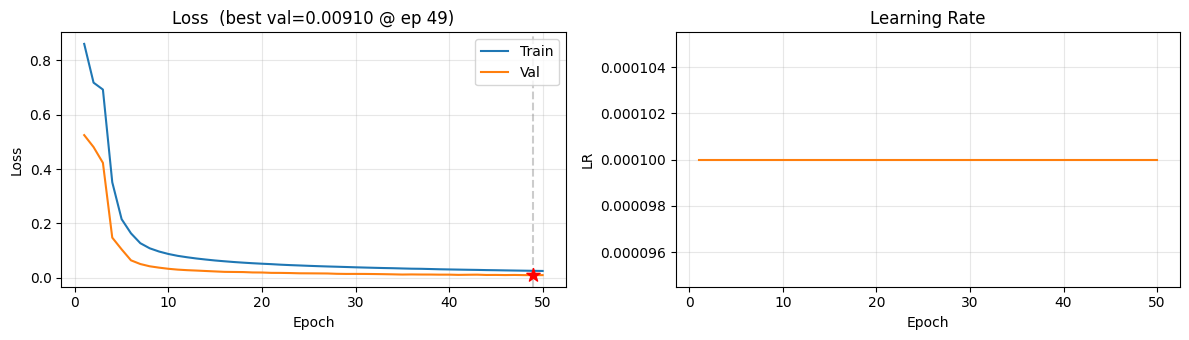

Epochs:   0%|          | 0/50 [00:00<?, ?ep/s]


Done — best val loss: 0.009100


In [10]:
trainer, history = train(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-4,
    patience=15,
    checkpoint_dir="../../checkpoints/power/full",
)

In [11]:
history.display_table(last_n=10)

Epoch,Train Loss,Val Loss,LR,Time
41,0.029561,0.010152,1.00e-04,1.0s
42,0.028956,0.010598,1.00e-04,1.0s
43,0.028454,0.010917,1.00e-04,1.0s
44,0.027732,0.009795,1.00e-04,1.0s
45,0.027260,0.009954,1.00e-04,1.0s
46,0.026656,0.009447,1.00e-04,1.0s
47,0.026118,0.009847,1.00e-04,1.0s
48,0.025598,0.009286,1.00e-04,1.0s
49,0.025086,0.009100,1.00e-04,1.0s
50,0.024583,0.009249,1.00e-04,1.0s


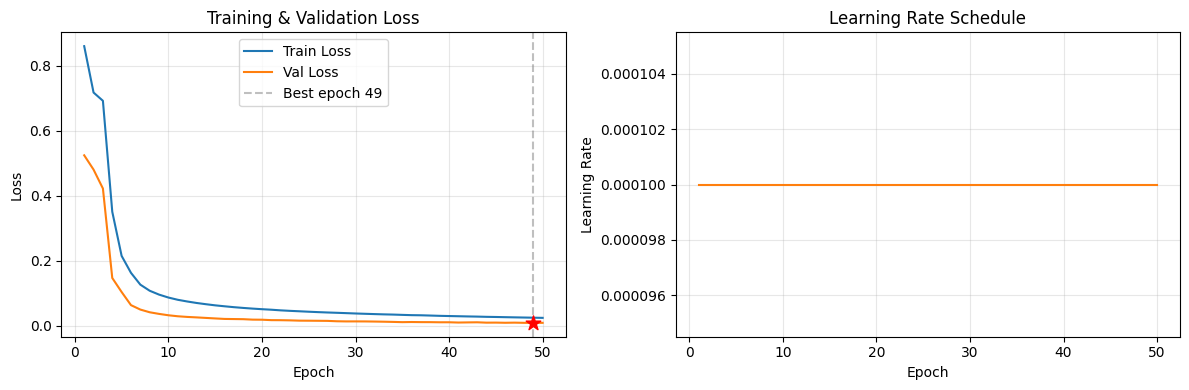

In [12]:
history.plot_learning_curves()

In [13]:
print(f"Best val loss: {trainer.best_val_loss:.6f}")
print(f"Checkpoint:    ../../checkpoints/power/full/best_model.pt")

Best val loss: 0.009100
Checkpoint:    ../../checkpoints/power/full/best_model.pt
